In [1]:
from langgraph.graph import START, StateGraph
from typing import TypedDict


# Define subgraph
class SubgraphState(TypedDict):
    foo: str  # note that this key is shared with the parent graph state
    bar: str


def subgraph_node_1(state: SubgraphState):
    return {"bar": "bar"}


def subgraph_node_2(state: SubgraphState):
    # note that this node is using a state key ('bar') that is only available in the subgraph
    # and is sending update on the shared state key ('foo')
    return {"foo": state["foo"] + state["bar"]}


subgraph_builder = StateGraph(SubgraphState)
subgraph_builder.add_node(subgraph_node_1)
subgraph_builder.add_node(subgraph_node_2)
subgraph_builder.add_edge(START, "subgraph_node_1")
subgraph_builder.add_edge("subgraph_node_1", "subgraph_node_2")
subgraph = subgraph_builder.compile()


# Define parent graph
class ParentState(TypedDict):
    foo: str


def node_1(state: ParentState):
    return {"foo": "hi! " + state["foo"]}


builder = StateGraph(ParentState)
builder.add_node("node_1", node_1)
# note that we're adding the compiled subgraph as a node to the parent graph
builder.add_node("node_2", subgraph)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
graph2 = builder.compile()

In [ ]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph2.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
for chunk in graph2.stream({"foo": "foo"}):
    print(chunk)

In [4]:
# from langchain.prompts import PromptTemplate

# # Correctly formatted JSON template
# json_template = '''{
#   "instruction": "Generate a report",
#   "parameters": {
#     "name": "{name}",
#     "age": "{age}",
#     "location": "{location}"
#   },
#   "format": "JSON"
# }'''

# # Create a PromptTemplate
# template = PromptTemplate(
#     input_variables=["name", "age", "location"],
#     template=json_template
# )

# # Generate the dynamic JSON message

# filled_message = template.format(name="John Doe", age="30", location="New York")
# print(filled_message)



In [4]:
import sys
import os

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add parent directory to sys.path
sys.path.append(parent_dir)

In [6]:

from agents.drafter import EmailDrafter
from langgraph.graph import StateGraph, MessagesState, START, END
from state import AgentGraphState
from langgraph.prebuilt import ToolNode, tools_condition
from state import state

from tools.product_enquiry import get_product_enquiry_tool
# from tools.product_enquiry import get_integrations
from tools.calendar import calender_availability
from tools.project_management import project_management


tools = [get_product_enquiry_tool(), calender_availability, project_management]
tool_node = ToolNode(tools)

workflow = StateGraph(AgentGraphState)
tool_node= ToolNode(tools)
email_drafter_agent= EmailDrafter(
    model= "gpt-4o-mini",
    state= state,
    server="openai"
)

print("bind started sucessfully")

email_drafter_agent.bind_tools(tools)
print("bind completed sucessfully")
# Define the two nodes we will cycle between
workflow.add_node("email_drafter", email_drafter_agent.call_model)
workflow.add_node("tools", tool_node)


# workflow.add_node("query_rewriter", email_drafter_agent.query_rewriter)  # Re-writing the question
# workflow.add_node("generator", email_drafter_agent.generate)

workflow.add_edge(START, "email_drafter")

# Decide whether to tools
# workflow.add_conditional_edges(
#     "email_drafter",
#     # Assess agent decision
#     tools_condition,
#     {
#         # Translate the condition outputs to nodes in our graph
#         "tools": "tools",
#         END: END,
#     },
# )
workflow.add_conditional_edges("email_drafter", email_drafter_agent.should_continue, ["tools", END])

# workflow.add_conditional_edges("tools",email_drafter_agent.grade_documents) 
workflow.add_edge("tools", "email_drafter")

# workflow.add_edge("generator", END)
# workflow.add_edge("query_rewriter", "email_drafter")
email_drafter_graph = workflow.compile()


called product enquiry tool
bind started sucessfully
bind completed sucessfully


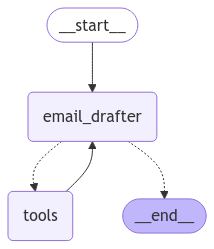

In [7]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(email_drafter_graph.get_graph(xray=1).draw_mermaid_png()))

In [54]:
from langchain_core.tools import tool
from langgraph.types import Command

In [29]:
@tool
def add(a: int, b: int) -> int:
    """Adds two numbers."""
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b

In [31]:
from typing import Annotated

from langchain_core.tools import tool
from langchain_core.tools.base import InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langchain_openai import ChatOpenAI

def make_handoff_tool(*, agent_name: str):
    """Create a tool that can return handoff via a Command"""
    tool_name = f"transfer_to_{agent_name}"

    @tool(tool_name)
    def handoff_to_agent(
        # # optionally pass current graph state to the tool (will be ignored by the LLM)
        state: Annotated[dict, InjectedState],
        # optionally pass the current tool call ID (will be ignored by the LLM)
        tool_call_id: Annotated[str, InjectedToolCallId],
    ):
        """Ask another agent for help."""
        tool_message = {
            "role": "tool",
            "content": f"Successfully transferred to {agent_name}",
            "name": tool_name,
            "tool_call_id": tool_call_id,
        }
        return Command(
            # navigate to another agent node in the PARENT graph
            goto=agent_name,
            graph=Command.PARENT,
            # This is the state update that the agent `agent_name` will see when it is invoked.
            # We're passing agent's FULL internal message history AND adding a tool message to make sure
            # the resulting chat history is valid. See the paragraph above for more information.
            update={"messages": state["messages"] + [tool_message]},
        )

    return handoff_to_agent

In [ ]:
model= ChatOpenAI(
    model="gpt-4o-mini", temperature=0
)

In [49]:
from langgraph.prebuilt import create_react_agent

addition_expert = create_react_agent(
    model,
    [add, make_handoff_tool(agent_name="calendar")],
    state_modifier="You are an addition expert, you can ask the calendar  for help with scheduling meetings.",
)

multiplication_expert = create_react_agent(
    model,
    [multiply, make_handoff_tool(agent_name="addition_expert")],
    state_modifier="You are a multiplication expert, you can ask an addition expert for help with addition.",
)

builder = StateGraph(MessagesState)
builder.add_node("addition_expert", addition_expert)
builder.add_edge(START, "addition_expert")
graph2 = builder.compile()

In [ ]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph2.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
# agent = make_agent(model, [add, multiply])

for chunk in graph2.stream({"messages": [("user", "what's (3 + 5)  and lets schedule a meet at 3PM today")]}):
    pretty_print_messages(chunk)

In [15]:
from typing_extensions import Literal
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.types import Command


def make_agent(model, tools, system_prompt=None):
    model_with_tools = model.bind_tools(tools)
    tools_by_name = {tool.name: tool for tool in tools}

    def call_model(state: MessagesState) -> Command[Literal["call_tools", "__end__"]]:
        messages = state["messages"]
        if system_prompt:
            messages = [{"role": "system", "content": system_prompt}] + messages

        response = model_with_tools.invoke(messages)
        if len(response.tool_calls) > 0:
            return Command(goto="call_tools", update={"messages": [response]})

        return {"messages": [response]}

    # NOTE: this is a simplified version of the prebuilt ToolNode
    # If you want to have a tool node that has full feature parity, please refer to the source code
    def call_tools(state: MessagesState) -> Command[Literal["call_model"]]:
        tool_calls = state["messages"][-1].tool_calls
        results = []
        for tool_call in tool_calls:
            tool_ = tools_by_name[tool_call["name"]]
            tool_input_fields = tool_.get_input_schema().model_json_schema()[
                "properties"
            ]

            # this is simplified for demonstration purposes and
            # is different from the ToolNode implementation
            if "state" in tool_input_fields:
                # inject state
                tool_call = {**tool_call, "args": {**tool_call["args"], "state": state}}

            tool_response = tool_.invoke(tool_call)
            if isinstance(tool_response, ToolMessage):
                results.append(Command(update={"messages": [tool_response]}))

            # handle tools that return Command directly
            elif isinstance(tool_response, Command):
                results.append(tool_response)

        # NOTE: nodes in LangGraph allow you to return list of updates, including Command objects
        return results

    graph2 = StateGraph(MessagesState)
    graph2.add_node(call_model)
    graph2.add_node(call_tools)
    graph2.add_edge(START, "call_model")
    graph2.add_edge("call_tools", "call_model")

    return graph2.compile()

In [ ]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph2.get_graph(xray=1).draw_mermaid_png()))

In [ ]:
for chunk in graph2.stream(
    {"messages": [("user", "what's (3 + 5) * 12")]}, subgraphs=True
):
    pretty_print_messages(chunk)

In [21]:
from langchain_core.messages import convert_to_messages


def pretty_print_messages(update):
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")

    for node_name, node_update in update.items():
        print(f"Update from node {node_name}:")
        print("\n")

        for m in convert_to_messages(node_update["messages"]):
            m.pretty_print()
        print("\n")

In [21]:
from typing_extensions import Literal
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langchain_anthropic import ChatAnthropic
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.types import Command

model = ChatAnthropic(model="claude-3-5-sonnet-latest")


@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help."""
    # This tool is not returning anything: we're just using it
    # as a way for LLM to signal that it needs to hand off to another agent
    # (See the paragraph above)
    return


@tool
def transfer_to_addition_expert():
    """Ask addition agent for help."""
    return


def addition_expert(
    state: MessagesState,
) -> Command[Literal["multiplication_expert", "__end__"]]:
    system_prompt = (
        "You are an addition expert, you can ask the multiplication expert for help with multiplication. "
        "Always do your portion of calculation before the handoff."
    )
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = model.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
    # If there are tool calls, the LLM needs to hand off to another agent
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        # NOTE: it's important to insert a tool message here because LLM providers are expecting
        # all AI messages to be followed by a corresponding tool result message
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(
            goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]}
        )

    # If the expert has an answer, return it directly to the user
    return {"messages": [ai_msg]}


def multiplication_expert(
    state: MessagesState,
) -> Command[Literal["addition_expert", "__end__"]]:
    system_prompt = (
        "You are a multiplication expert, you can ask an addition expert for help with addition. "
        "Always do your portion of calculation before the handoff."
    )
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    ai_msg = model.bind_tools([transfer_to_addition_expert]).invoke(messages)
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="addition_expert", update={"messages": [ai_msg, tool_msg]})

    return {"messages": [ai_msg]}

In [32]:
add_react = create_react_agent(
    model,
    [add, make_handoff_tool(agent_name="multiplication_expert")],
    state_modifier="You are an addition and product enquiry expert, you can ask the multiplication expert for help with multiplication.",
)


In [36]:
builder = StateGraph(MessagesState)

builder.add_node("addition_expert", addition_expert
)
builder.add_node("multiplication_expert", multiplication_expert)
# we'll always start with the addition expert
builder.add_edge(START, "addition_expert")
graph3 = builder.compile()

In [ ]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph3.get_graph(xray=1).draw_mermaid_png()))

In [39]:
for chunk in graph3.stream(
    {"messages": [("user", "what's (3 + 5) * 12")]}, subgraphs=True
):
    pretty_print_messages(chunk)

In [2]:
from langgraph.graph import StateGraph, MessagesState, START, END


In [ ]:
workflow = StateGraph(AgentGraphState)
tool_node= ToolNode(tools)
email_drafter_agent= EmailDrafter(
    model= "gpt-4o-mini",
    state= state,
    server="openai"
)

print("bind started sucessfully")

email_drafter_agent.bind_tools(tools)
print("bind completed sucessfully")
# Define the two nodes we will cycle between
workflow.add_node("email_drafter", email_drafter_agent.call_model)
workflow.add_node("tools", tool_node)

workflow.add_node("query_rewriter", email_drafter_agent.query_rewriter)  # Re-writing the question
# workflow.add_node("generator", email_drafter_agent.generate)

workflow.add_edge(START, "email_drafter")

# Decide whether to tools
workflow.add_conditional_edges(
    "email_drafter",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "tools",
        END: END,
    },
)
# workflow.add_conditional_edges("email_drafter", email_drafter_agent.should_continue, ["tools", END])

workflow.add_conditional_edges("tools",email_drafter_agent.grade_documents) 
workflow.add_edge("tools", "email_drafter")

# workflow.add_edge("generator", END)
workflow.add_edge("query_rewriter", "email_drafter")
email_drafter_graph = workflow.compile()


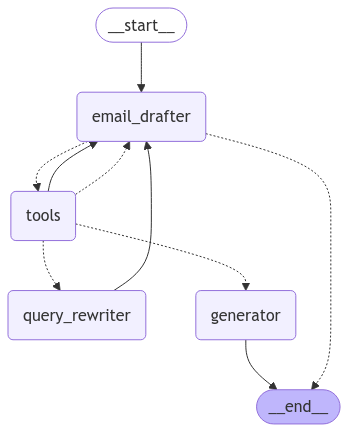

In [13]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(email_drafter_graph.get_graph(xray=1).draw_mermaid_png()))

In [38]:
from typing_extensions import Literal
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langchain_anthropic import ChatAnthropic
from langgraph.graph import MessagesState, StateGraph, START
from langgraph.types import Command
from langgraph.prebuilt import create_react_agent

model = ChatAnthropic(model="claude-3-5-sonnet-latest")


@tool
def transfer_to_multiplication_expert():
    """Ask multiplication agent for help."""
    # This tool is not returning anything: we're just using it
    # as a way for LLM to signal that it needs to hand off to another agent
    # (See the paragraph above)
    return


@tool
def transfer_to_calender_agent():
    """Ask calendar agent for help."""
    # This tool is not returning anything: we're just using it
    # as a way for LLM to signal that it needs to hand off to another agent
    # (See the paragraph above)
    return

@tool
def transfer_to_addition_expert():
    """Ask addition agent for help."""
    return

addition_expert = create_react_agent(
    model,
    [add, make_handoff_tool(agent_name="multiplication_expert"), make_handoff_tool(agent_name="calendar")],
    state_modifier="You are an addition expert, you can ask the multiplication expert for help with multiplication and calendar when you need help with scheduling meetings",
)

multiplication_expert = create_react_agent(
    model,
    [add, make_handoff_tool(agent_name="addition_expert")],
    state_modifier="You are an addition expert, you can ask the multiplication expert for help with multiplication",
)
# def addition_expert(
#     state: MessagesState,
# ) -> Command[Literal["multiplication_expert", "__end__"]]:
#     system_prompt = (
#         "You are an addition expert, you can ask the multiplication expert for help with multiplication. "
#         "Always do your portion of calculation before the handoff."
#     )
#     messages = [{"role": "system", "content": system_prompt}] + state["messages"]
#     ai_msg = model.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
#     # If there are tool calls, the LLM needs to hand off to another agent
#     if len(ai_msg.tool_calls) > 0:
#         tool_call_id = ai_msg.tool_calls[-1]["id"]
#         # NOTE: it's important to insert a tool message here because LLM providers are expecting
#         # all AI messages to be followed by a corresponding tool result message
#         tool_msg = {
#             "role": "tool",
#             "content": "Successfully transferred",
#             "tool_call_id": tool_call_id,
#         }
#         return Command(
#             goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]}
#         )

#     # If the expert has an answer, return it directly to the user
#     return {"messages": [ai_msg]}


# def multiplication_expert(
#     state: MessagesState,
# ) -> Command[Literal["addition_expert", "__end__"]]:
#     system_prompt = (
#         "You are a multiplication expert, you can ask an addition expert for help with addition. "
#         "Always do your portion of calculation before the handoff."
#     )
#     messages = [{"role": "system", "content": system_prompt}] + state["messages"]
#     ai_msg = model.bind_tools([transfer_to_addition_expert]).invoke(messages)
#     if len(ai_msg.tool_calls) > 0:
#         tool_call_id = ai_msg.tool_calls[-1]["id"]
#         tool_msg = {
#             "role": "tool",
#             "content": "Successfully transferred",
#             "tool_call_id": tool_call_id,
#         }
#         return Command(goto="addition_expert", update={"messages": [ai_msg, tool_msg]})

#     return {"messages": [ai_msg]}

In [39]:
builder = StateGraph(MessagesState)
builder.add_node("addition_expert", addition_expert)
builder.add_node("multiplication_expert", multiplication_expert)
# we'll always start with the addition expert
builder.add_edge(START, "addition_expert")
graph = builder.compile()

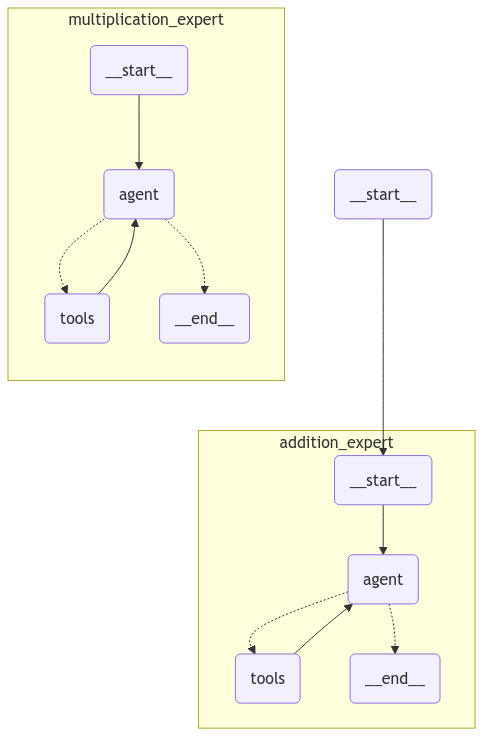

In [40]:
from IPython.display import Image, display

# Setting xray to 1 will show the internal structure of the nested graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [48]:
from typing import Annotated

from langchain_core.tools import tool
from langchain_core.tools.base import InjectedToolCallId
from langgraph.prebuilt import InjectedState


def make_handoff_tool(*, agent_name: str):
    """Create a tool that can return handoff via a Command"""
    tool_name = f"transfer_to_{agent_name}"

    @tool(tool_name)
    def handoff_to_agent(
        # # optionally pass current graph state to the tool (will be ignored by the LLM)
        state: Annotated[dict, InjectedState],
        # optionally pass the current tool call ID (will be ignored by the LLM)
        tool_call_id: Annotated[str, InjectedToolCallId],
    ):
        """Ask another agent for help."""
        tool_message = {
            "role": "tool",
            "content": f"Successfully transferred to {agent_name}",
            "name": tool_name,
            "tool_call_id": tool_call_id,
        }
        return Command(
            # navigate to another agent node in the PARENT graph
            goto=agent_name,
            graph=Command.PARENT,
            # This is the state update that the agent `agent_name` will see when it is invoked.
            # We're passing agent's FULL internal message history AND adding a tool message to make sure
            # the resulting chat history is valid. See the paragraph above for more information.
            update={"messages": state["messages"] + [tool_message]},
        )

    return handoff_to_agent

In [49]:
from langgraph.prebuilt import create_react_agent

addition_expert = create_react_agent(
    model,
    [add, make_handoff_tool(agent_name="multiplication_expert")],
    state_modifier="You are an addition expert, you can ask the multiplication expert for help with multiplication.",
)

multiplication_expert = create_react_agent(
    model,
    [multiply, make_handoff_tool(agent_name="addition_expert")],
    state_modifier="You are a multiplication expert, you can ask an addition expert for help with addition.",
)

builder = StateGraph(MessagesState)
builder.add_node("addition_expert", addition_expert)
builder.add_node("multiplication_expert", multiplication_expert)
builder.add_edge(START, "addition_expert")
graph = builder.compile()

In [50]:
for chunk in graph.stream(
    {"messages": [("user", "what's (3 + 5)/8  * 8")]}
):
    pretty_print_messages(chunk)

ValueError: ToolMessage.tool_call_id must match the tool call id. Expected: toolu_01LGSMPMn4RwX4e1ynXeov8x, got: toolu_01DMywga8NxLPPeqDrPR1zwr for tool 'transfer_to_multiplication_expert'.

In [1]:
import utils

ModuleNotFoundError: No module named 'utils'

: 